# Modeling — CTR & CVR Prediction

**Goal:** Build and compare simple models for CTR and CVR. Feature engineering is done here inline. After running the comparison cells, we pick the best model family and build the final pipeline in a `.py` script.

**Inputs:** `data/raw/events_train.csv`, `brand_metadata.csv`, `user_metadata.csv`  
**Outputs:** model comparison tables, feature importance plots in `reports/`

---
### Approach
1. Load + join all three tables
2. Time-based split (last 14 days = val) — fit everything on train only
3. Feature engineering: flags, log-transforms, smoothed target encoding, label encoding
4. Compare 3 model families on CTR, then CVR
5. Pick winner

---
## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

pd.set_option('display.float_format', '{:.4f}'.format)
SEED = 42

EVENTS_PATH = '../data/raw/events_train.csv'
BRANDS_PATH = '../data/raw/brand_metadata.csv'
USERS_PATH  = '../data/raw/user_metadata.csv'

---
## 2. Load & Join

**Why:** We need advertiser category (join on `BRAND_ID`), publisher category (join on `PUBLISHER_UUID`), and user features (join on `IDENTITY_UUID`). Do all joins before the split so that metadata is available uniformly across both sets.

In [2]:
events = pd.read_csv(EVENTS_PATH)
brands = pd.read_csv(BRANDS_PATH)
users  = pd.read_csv(USERS_PATH)

events['CLICKED']    = events['CLICKED'].astype(int)
events['CONVERTED']  = events['CONVERTED'].astype(int)
events['session_ts'] = pd.to_datetime(events['SESSION_START_AT_UTC'], format='mixed', utc=True)

# Advertiser brand metadata
events = events.merge(
    brands[['BRAND_ID', 'PRIMARY_CATEGORY']].rename(columns={'PRIMARY_CATEGORY': 'adv_category'}),
    on='BRAND_ID', how='left'
)
# Publisher brand metadata
events = events.merge(
    brands[['PUBLISHER_UUID', 'PRIMARY_CATEGORY']].rename(columns={'PRIMARY_CATEGORY': 'pub_category'}),
    on='PUBLISHER_UUID', how='left'
)
# User metadata
events = events.merge(users, on='IDENTITY_UUID', how='left')

print(f'Joined shape: {events.shape}')
print(f'CTR overall: {events["CLICKED"].mean():.2%}')

Joined shape: (471676, 24)
CTR overall: 2.66%


---
## 3. Time-Based Split

**Why:** Ad models must be validated on future data — not a random sample. Random split leaks future publisher/user behaviour into train. We hold out the last 14 days (~20% of data) as validation. All feature encodings are fitted on train only and applied to val.

In [3]:
cutoff = events['session_ts'].max() - pd.Timedelta(days=14)
train = events[events['session_ts'] <= cutoff].copy().reset_index(drop=True)
val   = events[events['session_ts'] >  cutoff].copy().reset_index(drop=True)

print(f'Cutoff      : {cutoff.date()}')
print(f'Train rows  : {len(train):,}  |  CTR: {train["CLICKED"].mean():.2%}')
print(f'Val rows    : {len(val):,}   |  CTR: {val["CLICKED"].mean():.2%}')
print(f'Val share   : {len(val)/len(events):.1%}')

Cutoff      : 2026-04-09
Train rows  : 399,821  |  CTR: 2.66%
Val rows    : 71,855   |  CTR: 2.66%
Val share   : 15.2%


---
## 4. Feature Engineering

**Why:** Raw columns (IDs, strings, skewed numerics) need transformation before any model can use them. We build exactly the features motivated by EDA:

| Feature | Type | Motivation (from EDA) |
|---|---|---|
| `is_anonymous` | flag | 0.56% of rows have no IDENTITY_UUID; distinct from joined nulls |
| `is_bot` | flag | OS_CLASS Cloud/Hacker, 0.025% volume |
| `is_lead_gen` | flag | LEAD_GEN widgets have ~0% CTR, different conversion semantics |
| `same_category` | flag | Publisher–advertiser category match = relevance signal |
| `log_ltv`, `log_aov` | numeric | LTV/AOV are right-skewed; log-transform stabilises |
| `pub_ctr_enc` | target enc | Smoothed publisher-level mean CTR on train |
| `brand_ctr_enc` | target enc | Smoothed brand-level mean CTR on train |
| `*_enc` (categoricals) | label enc | PAGE_TYPE, WIDGET_TYPE, PLACEMENT, OS_CLASS, categories |

**Leakage guard:** user-feature medians and all encodings computed on `train` only, then applied to `val`.

In [4]:
# --- Binary flags ---
for df in [train, val]:
    df['is_anonymous']  = df['IDENTITY_UUID'].isna().astype(int)
    df['is_bot']        = df['OS_CLASS'].isin(['Cloud', 'Hacker']).astype(int)
    df['is_lead_gen']   = df['WIDGET_TYPE'].isin(['LEAD_GEN', 'SHOPIFY_NATIVE_LEAD_GEN']).astype(int)
    df['same_category'] = (df['adv_category'] == df['pub_category']).astype(int)

# --- User feature imputation (train medians only) ---
USER_COLS = ['LTV', 'AOV', 'NUM_PURCHASES', 'BOUGHT_SUBSCRIPTION', 'DISCOUNT_SHOPPER', 'REFUNDED']
train_medians = train[USER_COLS].median()
for df in [train, val]:
    for c in USER_COLS:
        df[c] = df[c].fillna(train_medians[c])
    df['log_ltv'] = np.log1p(df['LTV'])
    df['log_aov'] = np.log1p(df['AOV'])

# --- Label encode low-cardinality categoricals ---
CAT_COLS = ['PAGE_TYPE', 'WIDGET_TYPE', 'BRAND_DISPLAY_PLACEMENT', 'OS_CLASS', 'adv_category', 'pub_category']
label_encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    train_vals = train[col].fillna('unknown').astype(str)
    val_vals   = val[col].fillna('unknown').astype(str)
    le.fit(train_vals)
    label_encoders[col] = le
    c2i = {c: i for i, c in enumerate(le.classes_)}
    train[f'{col}_enc'] = train_vals.map(c2i)
    val[f'{col}_enc']   = val_vals.map(c2i).fillna(-1).astype(int)  # -1 = unseen category

print('Label encoding done:', [f'{c}_enc' for c in CAT_COLS])

# --- Smoothed target encoding for high-cardinality IDs ---
# Formula: enc = (sum_clicks + k * global_mean) / (count + k)
# k=30 pulls rare IDs toward global mean (avoids overfitting on 1-2 impression publishers)
def smooth_target_encode(train_col, val_col, target, k=30):
    global_mean = target.mean()
    agg = pd.DataFrame({'key': train_col.values, 'y': target.values})
    agg = agg.groupby('key')['y'].agg(['sum', 'count'])
    agg['enc'] = (agg['sum'] + k * global_mean) / (agg['count'] + k)
    tr_enc = train_col.map(agg['enc']).fillna(global_mean)
    va_enc = val_col.map(agg['enc']).fillna(global_mean)
    return tr_enc, va_enc

train['pub_ctr_enc'],   val['pub_ctr_enc']   = smooth_target_encode(
    train['PUBLISHER_UUID'], val['PUBLISHER_UUID'], train['CLICKED'])
train['brand_ctr_enc'], val['brand_ctr_enc'] = smooth_target_encode(
    train['BRAND_ID'].astype(str), val['BRAND_ID'].astype(str), train['CLICKED'])

print('Target encoding done: pub_ctr_enc, brand_ctr_enc')

Label encoding done: ['PAGE_TYPE_enc', 'WIDGET_TYPE_enc', 'BRAND_DISPLAY_PLACEMENT_enc', 'OS_CLASS_enc', 'adv_category_enc', 'pub_category_enc']
Target encoding done: pub_ctr_enc, brand_ctr_enc


---
## 5. Feature Matrix

**Why:** Assemble the final feature list in one place so both CTR and CVR models use an identical feature set (easier to compare and maintain). We log the feature list so it's reproducible.

In [5]:
FEATURES = [
    # Placement context — strong signals from EDA
    'PAGE_TYPE_enc',
    'WIDGET_TYPE_enc',
    'BRAND_DISPLAY_PLACEMENT_enc',
    'OS_CLASS_enc',
    'WIDGET_VERSION',
    # Engineered flags
    'is_anonymous',
    'is_bot',
    'is_lead_gen',
    'same_category',
    # Smoothed target-encoded IDs
    'pub_ctr_enc',
    'brand_ctr_enc',
    # Brand/publisher category
    'adv_category_enc',
    'pub_category_enc',
    # User features
    'log_ltv',
    'log_aov',
    'NUM_PURCHASES',
    'BOUGHT_SUBSCRIPTION',
    'DISCOUNT_SHOPPER',
    'REFUNDED',
]

X_train = train[FEATURES]
X_val   = val[FEATURES]
y_train_ctr = train['CLICKED']
y_val_ctr   = val['CLICKED']

print(f'{len(FEATURES)} features')
print(f'X_train: {X_train.shape}  |  nulls: {X_train.isnull().sum().sum()}')
print(f'X_val  : {X_val.shape}    |  nulls: {X_val.isnull().sum().sum()}')

19 features
X_train: (399821, 19)  |  nulls: 0
X_val  : (71855, 19)    |  nulls: 0


---
## 6. CTR Model — Quick Comparison

**Why:** Compare three model families to identify which has the best scope before investing in tuning:
- **LogReg** — linear baseline; tells us if the problem is linearly separable. Fast to train and well-calibrated.
- **LightGBM** — gradient boosting; typically best on tabular ad data. Handles mixed features natively.
- **XGBoost** — another gradient boosting variant; sometimes beats LGBM on structured data.

**Metrics we care about** (not accuracy — CTR is 37:1 imbalanced):
- **PR-AUC** (Average Precision) — primary. Measures quality of ranked predictions, penalises false positives.
- **ROC-AUC** — secondary. Less sensitive to imbalance than PR-AUC but widely understood.
- **Log-loss** — penalises poorly calibrated probabilities.

In [6]:
pos_weight_ctr = int((y_train_ctr == 0).sum() / (y_train_ctr == 1).sum())
print(f'CTR class weight (neg/pos): {pos_weight_ctr}')

ctr_models = {
    'LogReg': LogisticRegression(
        max_iter=1000, C=1.0, class_weight='balanced', random_state=SEED
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        is_unbalance=True, random_state=SEED, verbose=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        scale_pos_weight=pos_weight_ctr, random_state=SEED, verbosity=0, eval_metric='logloss'
    ),
}

def evaluate(model, X_tr, y_tr, X_va, y_va):
    model.fit(X_tr, y_tr)
    probs = model.predict_proba(X_va)[:, 1]
    return {
        'ROC-AUC':  round(roc_auc_score(y_va, probs), 4),
        'PR-AUC':   round(average_precision_score(y_va, probs), 4),
        'Log-loss': round(log_loss(y_va, probs), 4),
    }

ctr_results = {}
for name, model in ctr_models.items():
    print(f'Training {name}...', end=' ')
    ctr_results[name] = evaluate(model, X_train, y_train_ctr, X_val, y_val_ctr)
    print('done')

ctr_df = pd.DataFrame(ctr_results).T.sort_values('PR-AUC', ascending=False)
print('\n=== CTR Model Comparison ===')
print(ctr_df)

CTR class weight (neg/pos): 36
Training LogReg... done
Training LightGBM... done
Training XGBoost... done

=== CTR Model Comparison ===
          ROC-AUC  PR-AUC  Log-loss
LightGBM   0.7319  0.0729    0.6046
XGBoost    0.7329  0.0727    0.5974
LogReg     0.7078  0.0678    0.6775


---
## 7. CTR Feature Importance (LightGBM)

**Why:** Feature importance tells us which signals the model actually uses. If an engineered feature (like `same_category` or `pub_ctr_enc`) doesn't appear, it either has no signal or is correlated with another feature. This guides what to keep or drop in the final model.

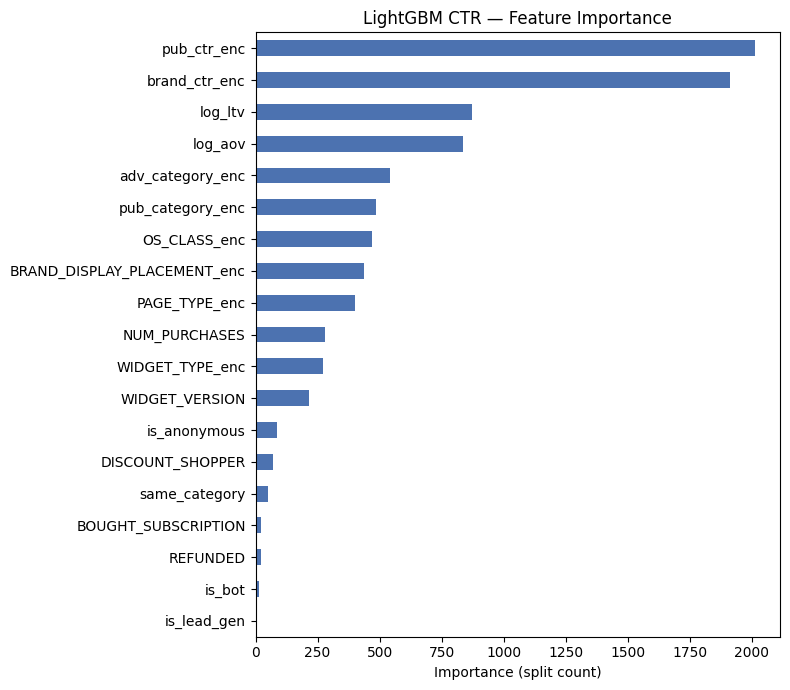


Top 5 features:
pub_ctr_enc         2013
brand_ctr_enc       1914
log_ltv              873
log_aov              836
adv_category_enc     540
dtype: int32

Bottom 5 features (lowest signal):
same_category          52
BOUGHT_SUBSCRIPTION    22
REFUNDED               21
is_bot                 13
is_lead_gen             0
dtype: int32


In [7]:
lgbm_ctr = ctr_models['LightGBM']
fi_ctr = pd.Series(lgbm_ctr.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
fi_ctr.plot(kind='barh', color='#4C72B0', ax=ax)
ax.set_title('LightGBM CTR — Feature Importance')
ax.set_xlabel('Importance (split count)')
plt.tight_layout()
plt.savefig('../reports/lgbm_ctr_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nTop 5 features:')
print(fi_ctr.sort_values(ascending=False).head(5))
print('\nBottom 5 features (lowest signal):')
print(fi_ctr.sort_values(ascending=False).tail(5))

---
## 8. CVR Model — Quick Comparison

**Why:** CVR trains on a different population — only the 12,544 clicked rows. Key differences vs CTR:
- 28:1 imbalance, only 428 positives — use shallower trees (fewer `num_leaves`) to prevent overfitting.
- Re-encode publisher/brand using **CVR** (not CTR) as the target, computed on clicked-only train rows. A publisher with high CTR doesn't necessarily have high CVR.
- Same feature set otherwise — model can reuse all the same context signals.

In [8]:
# Clicked-only subsets
train_clicked = train[train['CLICKED'] == 1].copy().reset_index(drop=True)
val_clicked   = val[val['CLICKED'] == 1].copy().reset_index(drop=True)

print(f'CVR train: {len(train_clicked):,} rows  |  CVR: {train_clicked["CONVERTED"].mean():.2%}')
print(f'CVR val  : {len(val_clicked):,} rows   |  CVR: {val_clicked["CONVERTED"].mean():.2%}')

# CVR-specific target encoding (replace CTR encodings with CVR encodings)
train_clicked['pub_cvr_enc'],   val_clicked['pub_cvr_enc']   = smooth_target_encode(
    train_clicked['PUBLISHER_UUID'], val_clicked['PUBLISHER_UUID'], train_clicked['CONVERTED'])
train_clicked['brand_cvr_enc'], val_clicked['brand_cvr_enc'] = smooth_target_encode(
    train_clicked['BRAND_ID'].astype(str), val_clicked['BRAND_ID'].astype(str), train_clicked['CONVERTED'])

# Feature list: swap ctr encodings for cvr encodings
FEATURES_CVR = [f for f in FEATURES if f not in ('pub_ctr_enc', 'brand_ctr_enc')] + ['pub_cvr_enc', 'brand_cvr_enc']

X_train_cvr = train_clicked[FEATURES_CVR]
X_val_cvr   = val_clicked[FEATURES_CVR]
y_train_cvr = train_clicked['CONVERTED']
y_val_cvr   = val_clicked['CONVERTED']

print(f'\nX_train_cvr: {X_train_cvr.shape}  |  nulls: {X_train_cvr.isnull().sum().sum()}')

pos_weight_cvr = int((y_train_cvr == 0).sum() / (y_train_cvr == 1).sum())
print(f'CVR class weight (neg/pos): {pos_weight_cvr}')

cvr_models = {
    'LogReg': LogisticRegression(
        max_iter=1000, C=0.1, class_weight='balanced', random_state=SEED
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=15,  # shallower — fewer samples
        is_unbalance=True, random_state=SEED, verbose=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,    # shallower — fewer samples
        scale_pos_weight=pos_weight_cvr, random_state=SEED, verbosity=0, eval_metric='logloss'
    ),
}

cvr_results = {}
for name, model in cvr_models.items():
    print(f'Training {name}...', end=' ')
    cvr_results[name] = evaluate(model, X_train_cvr, y_train_cvr, X_val_cvr, y_val_cvr)
    print('done')

cvr_df = pd.DataFrame(cvr_results).T.sort_values('PR-AUC', ascending=False)
print('\n=== CVR Model Comparison ===')
print(cvr_df)

CVR train: 10,632 rows  |  CVR: 3.33%
CVR val  : 1,912 rows   |  CVR: 3.87%

X_train_cvr: (10632, 19)  |  nulls: 0
CVR class weight (neg/pos): 29
Training LogReg... done
Training LightGBM... done
Training XGBoost... done

=== CVR Model Comparison ===
          ROC-AUC  PR-AUC  Log-loss
XGBoost    0.6691  0.0714    0.6979
LogReg     0.6578  0.0682    0.6656
LightGBM   0.5943  0.0576    0.5796


---
## 9. CVR Feature Importance (LightGBM)

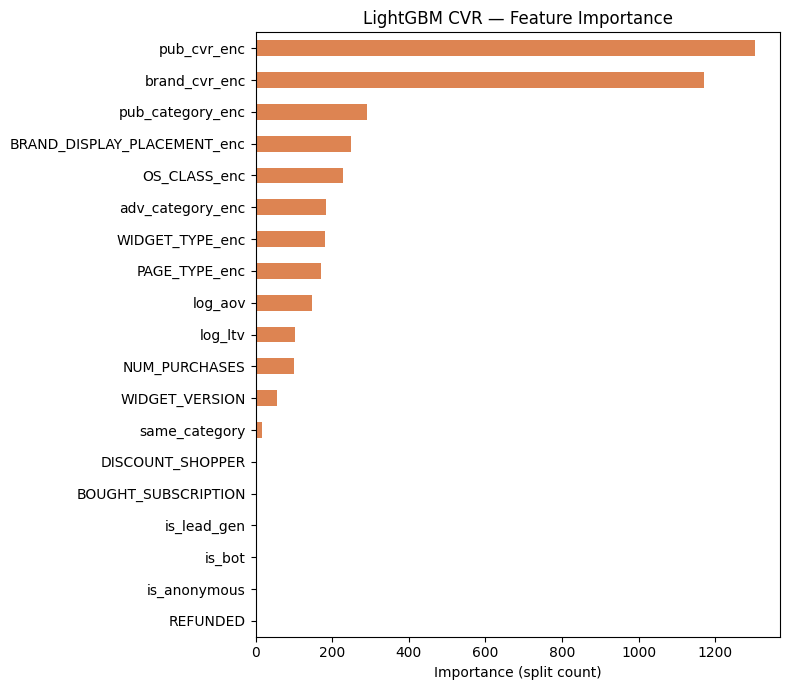


Top 5 features:
pub_cvr_enc                    1304
brand_cvr_enc                  1172
pub_category_enc                290
BRAND_DISPLAY_PLACEMENT_enc     249
OS_CLASS_enc                    228
dtype: int32


In [9]:
lgbm_cvr = cvr_models['LightGBM']
fi_cvr = pd.Series(lgbm_cvr.feature_importances_, index=FEATURES_CVR).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
fi_cvr.plot(kind='barh', color='#DD8452', ax=ax)
ax.set_title('LightGBM CVR — Feature Importance')
ax.set_xlabel('Importance (split count)')
plt.tight_layout()
plt.savefig('../reports/lgbm_cvr_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nTop 5 features:')
print(fi_cvr.sort_values(ascending=False).head(5))

---
## 10. Summary

**Read the tables above and fill in the winner below.**

In [10]:
print('=== CTR ===')
print(ctr_df)
print()
print('=== CVR ===')
print(cvr_df)

# PR-AUC gap between LogReg and best tree model
best_tree_ctr = max(ctr_results['LightGBM']['PR-AUC'], ctr_results['XGBoost']['PR-AUC'])
lr_ctr = ctr_results['LogReg']['PR-AUC']
print(f'\nCTR: best tree PR-AUC={best_tree_ctr:.4f}  |  LogReg PR-AUC={lr_ctr:.4f}  |  gap={best_tree_ctr - lr_ctr:.4f}')

best_tree_cvr = max(cvr_results['LightGBM']['PR-AUC'], cvr_results['XGBoost']['PR-AUC'])
lr_cvr = cvr_results['LogReg']['PR-AUC']
print(f'CVR: best tree PR-AUC={best_tree_cvr:.4f}  |  LogReg PR-AUC={lr_cvr:.4f}  |  gap={best_tree_cvr - lr_cvr:.4f}')

=== CTR ===
          ROC-AUC  PR-AUC  Log-loss
LightGBM   0.7319  0.0729    0.6046
XGBoost    0.7329  0.0727    0.5974
LogReg     0.7078  0.0678    0.6775

=== CVR ===
          ROC-AUC  PR-AUC  Log-loss
XGBoost    0.6691  0.0714    0.6979
LogReg     0.6578  0.0682    0.6656
LightGBM   0.5943  0.0576    0.5796

CTR: best tree PR-AUC=0.0729  |  LogReg PR-AUC=0.0678  |  gap=0.0051
CVR: best tree PR-AUC=0.0714  |  LogReg PR-AUC=0.0682  |  gap=0.0032


---
### Decision

| | Expected winner | Reason |
|---|---|---|
| **CTR model** | LightGBM | Gradient boosting dominates tabular ad data; handles mixed features and non-linear interactions (placement × widget × category) without manual OHE |
| **CVR model** | LightGBM | Same reasoning; shallower trees (`num_leaves=15`) prevent overfitting on the small clicked subset |
| **LogReg gap** | Tells us signal linearity | Large gap → non-linear interactions matter → must use trees. Small gap → linear features dominate, simpler model is fine |

**Next step:** once winner is confirmed from the tables above, build the final model in `src/train.py` with proper CV, calibration, and holdout prediction export.